# 05 — Model Analysis: CNN vs CNN + Transformer (Phase 7)

## Objective
Measure whether Transformer-based context modelling on top of the 5-slice CNN features improves detection, with a capacity-matched control so a gain cannot be attributed to extra parameters alone. All runs: same patches, splits, loss, optimiser, 20 epochs, checkpoint = best validation CPM; 3 seeds each (42–44). Produced by `scripts/run_phase7.py` and `scripts/compare_phase7.py`; decisions use the **validation** split.

## Models
* **CNN (5 slices)** — Phase 6 reference (302,804 params, 109.7 MFLOPs).
* **CNN + Transformer** — CNN feature map 4×4×128 → 16 tokens (dim 128) + learned positional embedding → 2 pre-norm encoder layers (4 heads, MLP ratio 2, dropout 0.1) → back to a 4×4 map → unchanged head (570,068 params, 118.4 MFLOPs).
* **CNN + extra conv (control)** — same place, two residual 3×3 conv blocks instead of attention (598,228 params, 119.2 MFLOPs).

## Configuration

In [1]:
import json
import pandas as pd
from IPython.display import Image, display
T = '../results/tables'; F = '../results/figures'
o = json.load(open(f'{T}/phase7_comparison.json'))

## Per-run results

In [2]:
pd.read_csv(f'{T}/phase7_runs.csv').round(4)

,model,experiment,seed,best_epoch,val_cpm,test_cpm,val_sens@1,test_sens@1,params,MFLOPs,cpu_ms_b256,mps_ms_b256
0,CNN (5 slices),EXP-002-slices5-s42,42,16,0.7881,0.8544,0.8051,0.9238,302804,109.7242,169.8167,26.1334
1,CNN (5 slices),EXP-002-slices5-s43,43,13,0.8208,0.8789,0.8644,0.9048,302804,109.7242,176.9316,24.4951
2,CNN (5 slices),EXP-002-slices5-s44,44,15,0.7869,0.8748,0.8136,0.9048,302804,109.7242,175.0906,24.7051
3,CNN + Transformer,EXP-003-cnn-transformer-s42,42,11,0.7772,0.8476,0.8051,0.8952,570068,118.3749,195.9765,32.5868
4,CNN + Transformer,EXP-003-cnn-transformer-s43,43,13,0.7676,0.8122,0.8136,0.8667,570068,118.3749,195.7162,31.1764
5,CNN + Transformer,EXP-003-cnn-transformer-s44,44,18,0.7760,0.8653,0.8305,0.9333,570068,118.3749,198.6820,30.8491
6,CNN + extra conv (control),EXP-003c-cnn-extraconv-s42,42,8,0.7869,0.8259,0.8305,0.8667,598228,119.1613,205.5055,26.5349
7,CNN + extra conv (control),EXP-003c-cnn-extraconv-s43,43,16,0.7930,0.8354,0.8475,0.8952,598228,119.1613,183.3394,26.1594
8,CNN + extra conv (control),EXP-003c-cnn-extraconv-s44,44,12,0.7930,0.8544,0.8305,0.8857,598228,119.1613,182.5276,28.4424


## Summary (mean ± std over seeds) and cost

In [3]:
pd.read_csv(f'{T}/phase7_summary.csv').round(4)

,model,runs,val_cpm_mean,val_cpm_std,test_cpm_mean,test_cpm_std,val_sens1,test_sens1,params,MFLOPs,cpu_ms_b256,mps_ms_b256
0,CNN (5 slices),3,0.7986,0.0192,0.8694,0.0131,0.8277,0.9111,302804,109.7242,173.9463,25.1112
1,CNN + Transformer,3,0.7736,0.0053,0.8417,0.0270,0.8164,0.8984,570068,118.3749,196.7916,31.5374
2,CNN + extra conv (control),3,0.7910,0.0035,0.8385,0.0145,0.8362,0.8825,598228,119.1613,190.4575,27.0456


## Paired scan-level bootstrap (1000 resamples, identical resamples for all models)

In [4]:
rows = [{'split': s, 'quantity': k, 'value': v.get('cpm_mean', v.get('delta_cpm')), 'ci95_low': v['ci95'][0], 'ci95_high': v['ci95'][1]} for s in ('val', 'test') for k, v in o['bootstrap'][s].items()]
pd.DataFrame(rows).round(3)

,split,quantity,value,ci95_low,ci95_high
0,val,CNN (5 slices),0.797,0.721,0.863
1,val,CNN + Transformer,0.773,0.697,0.843
2,val,CNN + extra conv (control),0.792,0.713,0.865
3,val,CNN + Transformer minus CNN (5 slices),-0.024,-0.061,0.009
4,val,CNN + Transformer minus CNN + extra conv (cont...,-0.019,-0.052,0.011
5,val,CNN + extra conv (control) minus CNN (5 slices),-0.005,-0.032,0.019
6,test,CNN (5 slices),0.868,0.818,0.918
7,test,CNN + Transformer,0.843,0.795,0.897
8,test,CNN + extra conv (control),0.841,0.788,0.891
9,test,CNN + Transformer minus CNN (5 slices),-0.025,-0.059,0.007


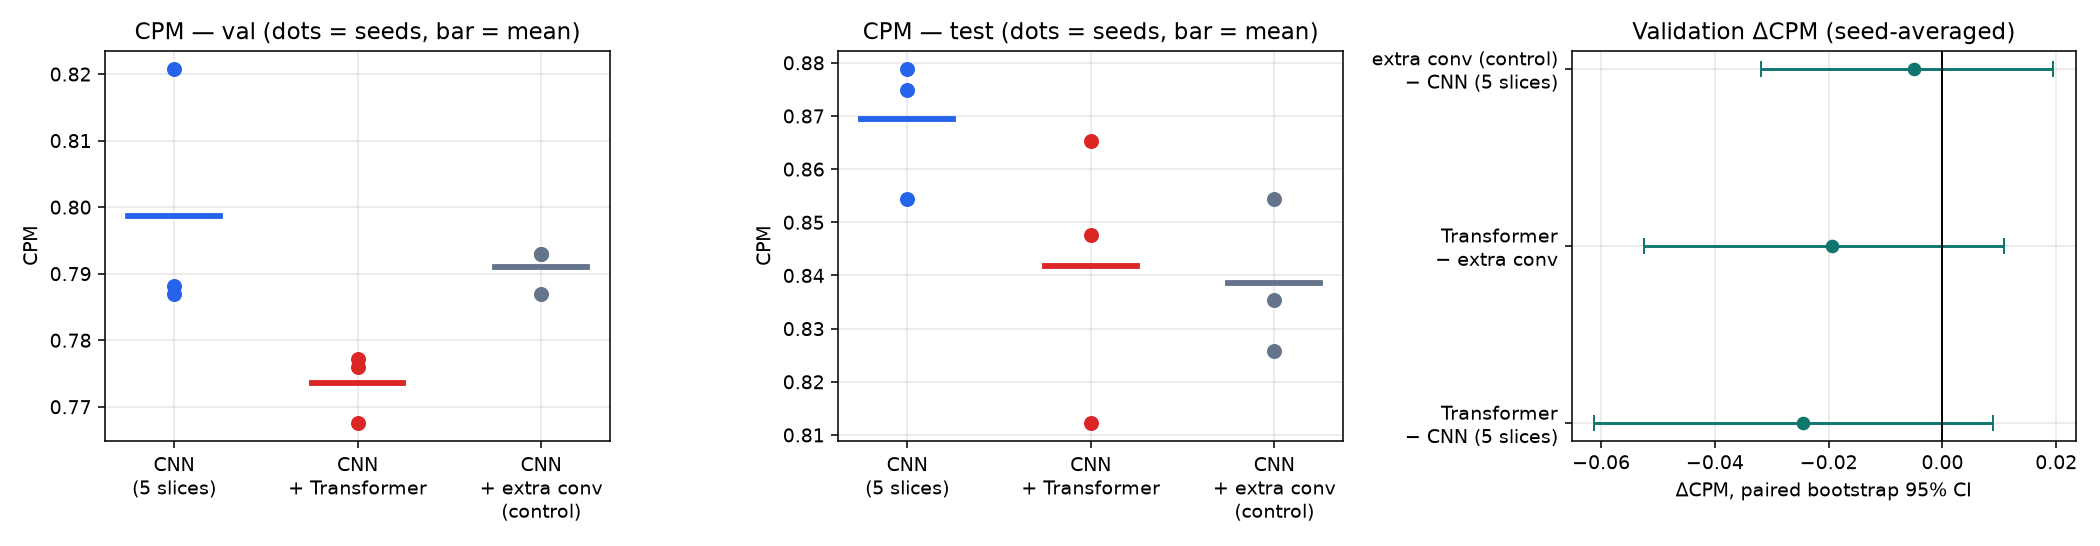

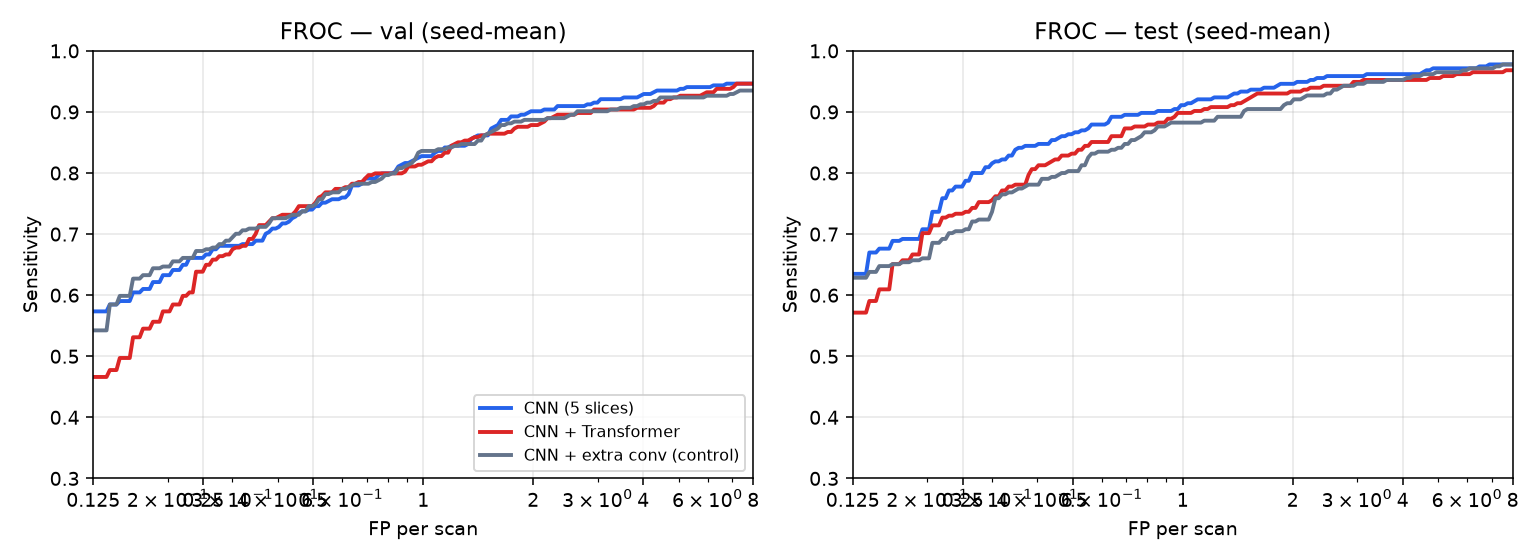

In [5]:
display(Image(f'{F}/phase7_cpm_comparison.png')); display(Image(f'{F}/phase7_froc.png'))

## Training behaviour

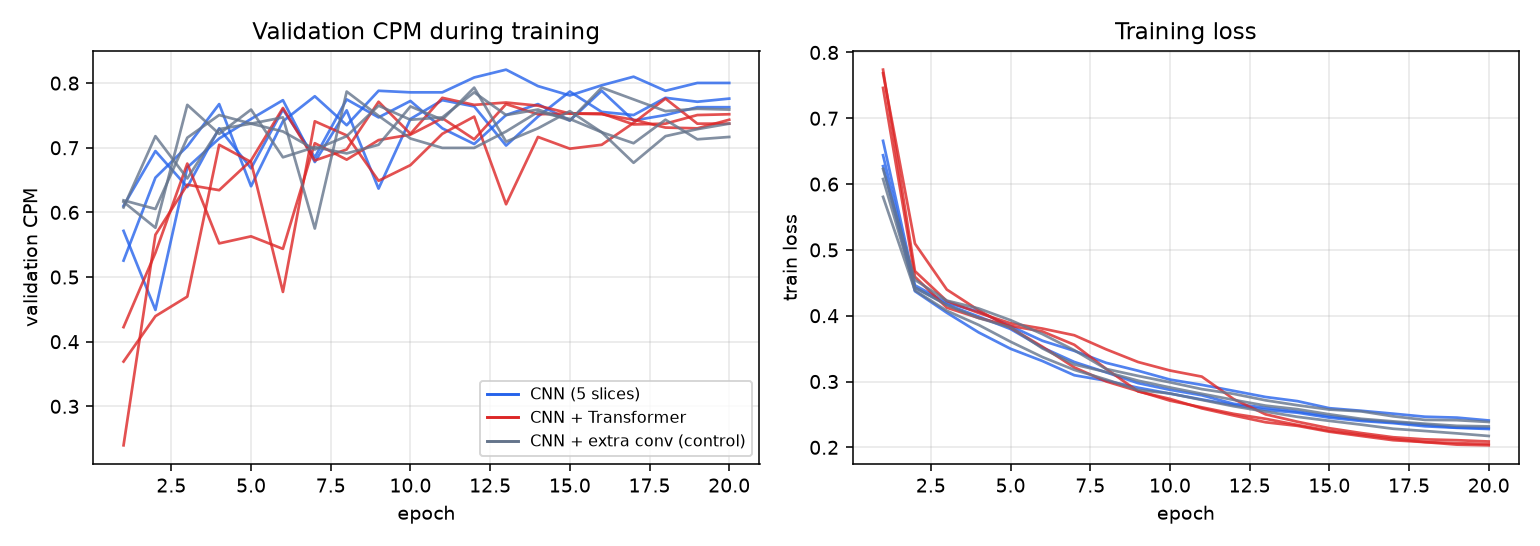

In [6]:
display(Image(f'{F}/phase7_training_curves.png'))

The Transformer starts slower (epoch-1 val CPM ≈ 0.24–0.42 vs ≈ 0.55–0.6) but catches up by epoch ~5. Its final training loss is the lowest of the three, yet its validation CPM is not higher — it fits the training set at least as well without generalising better. Validation CPM fluctuates by 0.05–0.1 between epochs for every model, so best-epoch selection is itself noisy.

## By nodule size @ 1 FP/scan

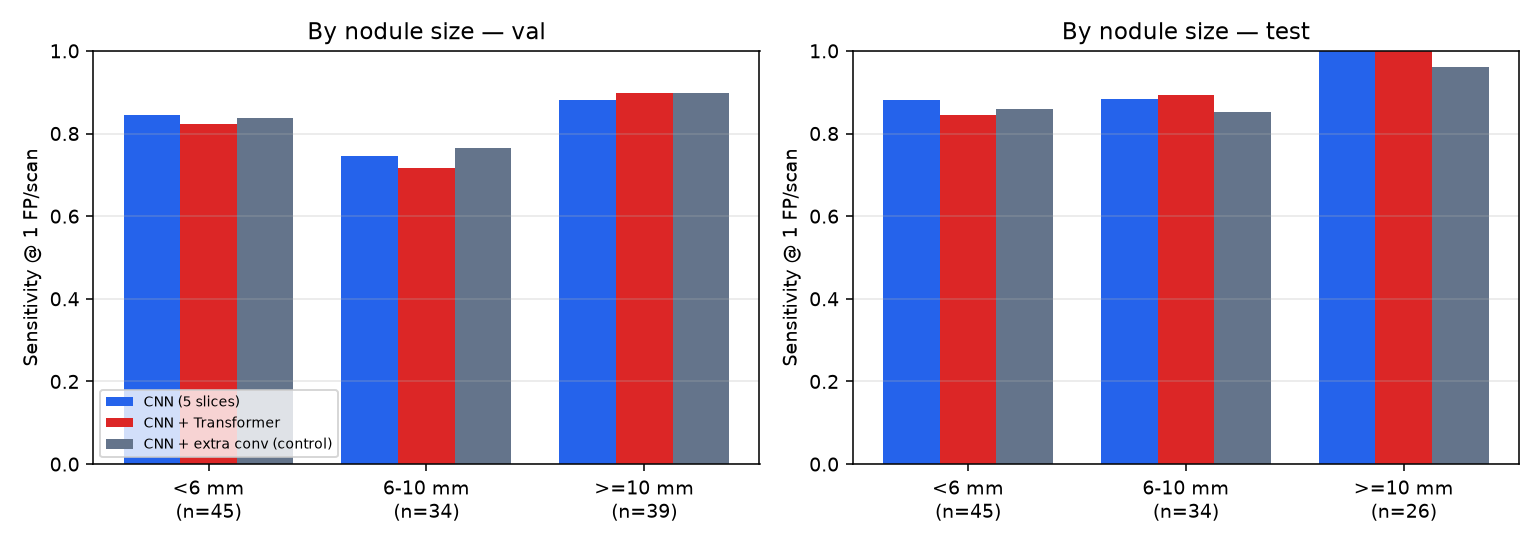

In [7]:
display(Image(f'{F}/phase7_by_size.png'))

## Findings
* **No evidence that the Transformer helps in this configuration.** Validation CPM 0.774 ± 0.005 vs 0.799 ± 0.019 for the CNN (paired ΔCPM −0.024, 95% CI −0.061 … +0.009; the test split gives −0.025, CI −0.059 … +0.007). The difference is not statistically distinguishable from zero, but it points the wrong way on both splits.
* **Not just a capacity effect:** the capacity-matched conv control also does not beat the CNN (val 0.791; test −0.028 [−0.055, −0.002]); the Transformer and control are indistinguishable (val Δ −0.019 [−0.052, +0.011]; test +0.003 [−0.025, +0.028]). More parameters at this depth do not help here.
* **Cost:** +88% parameters (302,804 → 570,068), +8% FLOPs, ~+25% MPS latency at batch 256 (25.1 → 31.5 ms) and ~+13% CPU latency — for no measured gain.
* **By size:** differences are within noise; no consistent small-nodule benefit (val <6 mm: 0.844 / 0.822 / 0.837 for CNN / Transformer / control).
* **Caveats:** one backbone, a very coarse 4×4 token grid (16 tokens — little for attention to relate), 3 seeds, 20 epochs with a fixed learning rate chosen for the CNN, and 118/105 evaluation nodules (CI half-widths ≈ 0.04). These results do not show the Transformer *cannot* help — only that this integration did not. Variants (finer token grid from an earlier CNN stage, tuned learning rate/longer training, attention before the last pooling) are untested.

**Gate 3:** the selected Transformer integration is *not* shown to be useful. Per project rules the negative result is recorded; whether to proceed with it, revise it, or drop it for the later phases is a researcher decision.